### Testing initializations
In this test, i will find the most suitable initialization technique for my model.
I will use the MNIST hand-written dataset.

#### We will maintain a structure of:
-layer design: 784 -> 64 -> 32 -> 10

-learning rate: 0.001  

-batch size: 32

-RMSProp optimizer

-5 epoch

#### And we change the hidden layers initializations into 3 diffrent values:

1- He initialization
2- Xavier initialization
#### Tests are evaluated based on: 
Training time, Testing accuracy, Testing loss

In [1]:
#Change directory for importing 

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
#Load and preprocess MNIST dataset from keras
from load_mnist import load_handwritten_digits

X_train, y_train, X_test, y_test = load_handwritten_digits()

In [4]:
import time #For calculating training time

initializations = ["He", "Xavier"]

initialization_results = dict() # {init: (acc, loss, time)}

from build_model import build_mnist_model

In [5]:
btchsize = 32
lr =0.001

In [8]:
for init in initializations:
    print(f"---------- {init} ----------")

    nn = build_mnist_model(optimizer ="RMSProp",
                          hidden_init= init)
    start = time.perf_counter() #Timer starts!

    nn.fit(X = X_train,
           y = y_train,
           epoch = 5,
           batch_size = btchsize,
           monitor_every_n = 5)

    elapsed = time.perf_counter() - start #Timer stops!
    accuracy, loss = nn.evaluate(X_test, y_test)

    initialization_results[init] = (accuracy, loss, elapsed)

    print(f"{init}, time: {elapsed}")
    print(f"{init}, accuracy: {accuracy}")
    print(f"{init}, loss: {loss}")

---------- He ----------
epoch: 5, loss: 0.04606113700307533
He, time: 46.819193899980746
He, accuracy: 0.9744
He, loss: 0.08316723982591233
---------- Xavier ----------
epoch: 5, loss: 0.046087915358909284
Xavier, time: 46.14166550000664
Xavier, accuracy: 0.9731
Xavier, loss: 0.08572245016801194


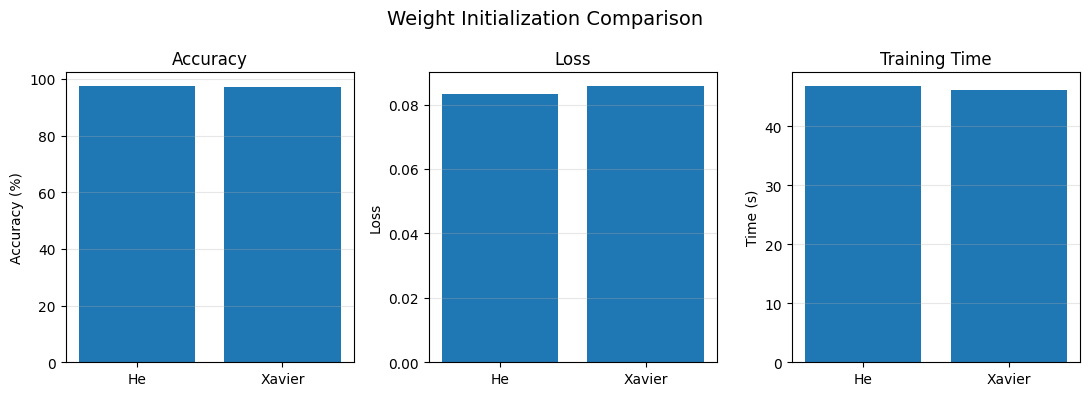

In [11]:
import matplotlib.pyplot as plt

accuracies = [initialization_results[x][0] * 100 for x in initializations]
losses = [initialization_results[x][1] for x in initializations]
times = [initialization_results[x][2] for x in initializations]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

# Accuracy
axes[0].bar(initializations, accuracies)
axes[0].set_title("Accuracy")
axes[0].set_ylabel("Accuracy (%)")
axes[0].grid(axis="y", alpha=0.3)

# Loss
axes[1].bar(initializations, losses)
axes[1].set_title("Loss")
axes[1].set_ylabel("Loss")
axes[1].grid(axis="y", alpha=0.3)

# Training time
axes[2].bar(initializations, times)
axes[2].set_title("Training Time")
axes[2].set_ylabel("Time (s)")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("Weight Initialization Comparison", fontsize=14)
plt.tight_layout()

plt.savefig("test_results\\initialization_test.png")
plt.show()

### Conclusion

plot shows that both initializations managed to get similiar and good losses and accuracies during the test, showing that
on a relatively simple problem, both methods will achieve the same results.

However, we can still notice some minor diffrencees in all of the metrics shown; That can indicate that on a more
complicated dataset or problem, He initialization generally offers the better results with less training time.


This also makes sense, since we used ReLU activations in all layers during the test and He initialization is speciefically
designed for ReLU

So a better testing design would be to use a harder dataset as the target and multiple other activation functions.